<a href="https://colab.research.google.com/github/EvelynRobert/US-Accident-Modeling-DS4420/blob/main/TimeSeriesFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Time Series Data Prep

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/content/accidents_sample.csv')

# keep relevant columns and drop rows missing a timestamp
cols = ['Start_Time', 'Severity', 'Temperature(F)', 'Humidity(%)',
        'Visibility(mi)', 'Weather_Condition', 'Sunrise_Sunset',
        'State', 'Distance(mi)']
df = df[cols].dropna(subset=['Start_Time'])
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df = df.dropna(subset=['Start_Time'])

# extract date parts from the timestamp
df['Date']      = df['Start_Time'].dt.date.astype(str)
df['Year']      = df['Start_Time'].dt.year.astype('int32')
df['Month']     = df['Start_Time'].dt.month.astype('int32')
df['Hour']      = df['Start_Time'].dt.hour.astype('int32')
df['DayOfWeek'] = df['Start_Time'].dt.dayofweek.astype('int32')

# fill missing numeric values with the column median
for col in ['Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Distance(mi)']:
    df[col] = df[col].fillna(df[col].median())

df.head()

,Start_Time,Severity,Temperature(F),Humidity(%),Visibility(mi),Weather_Condition,Sunrise_Sunset,State,Distance(mi),Date,Year,Month,Hour,DayOfWeek
0,2020-04-25 17:48:08,2,88.0,63.0,10.0,Mostly Cloudy,Day,FL,0.000,2020-04-25,2020,4,17,5
1,2021-03-29 23:34:00,2,44.0,40.0,10.0,Fair,Night,NJ,0.675,2021-03-29,2021,3,23,0
2,2019-05-20 16:33:45,3,85.0,41.0,10.0,Mostly Cloudy,Day,NJ,0.067,2019-05-20,2019,5,16,0
3,2021-07-02 22:39:00,2,76.0,64.0,10.0,Fair,Night,CA,0.321,2021-07-02,2021,7,22,4
5,2021-12-20 08:22:00,2,30.0,88.0,6.0,Fair,Day,AR,2.577,2021-12-20,2021,12,8,0


In [2]:
# count accidents per day and sort chronologically
daily_counts = df.groupby('Date').size().reset_index(name='Accident_Count')
daily_counts['Date'] = pd.to_datetime(daily_counts['Date'])
daily_counts = daily_counts.sort_values('Date').reset_index(drop=True)
daily_counts.head()

,Date,Accident_Count
0,2016-02-19,1
1,2016-02-23,1
2,2016-02-29,1
3,2016-03-24,1
4,2016-03-29,1


## Model 1: OLS Decomposition

In [3]:
# use the first 80% of days for training, the last 20% for testing
split = int(len(daily_counts) * 0.8)
print(f'Training on {split} days, testing on {len(daily_counts) - split} days')

Training on 1788 days, testing on 448 days


In [4]:
dates  = pd.to_datetime(daily_counts['Date'])
t_days = (dates - dates.iloc[0]).dt.days.values.astype(float)
t_norm = t_days / t_days.max()  # scale to [0,1] for numerical stability

n   = len(daily_counts)
dow = dates.dt.dayofweek.values

# sin/cos pairs encode the yearly cycle; 3 harmonics capture the shape
annual_feats = []
for k in range(1, 4):
    annual_feats.append(np.sin(2 * np.pi * k * t_days / 365.25))
    annual_feats.append(np.cos(2 * np.pi * k * t_days / 365.25))

# same idea for the weekly cycle using day-of-week
weekly_feats = []
for k in range(1, 4):
    weekly_feats.append(np.sin(2 * np.pi * k * dow / 7))
    weekly_feats.append(np.cos(2 * np.pi * k * dow / 7))

# binary flag for the COVID lockdown window
covid_start = pd.Timestamp('2020-03-01')
covid_end   = pd.Timestamp('2020-08-31')
covid_dummy = ((dates >= covid_start) & (dates <= covid_end)).astype(float).values

# assemble design matrix: intercept, linear trend, quadratic trend, annual, weekly, covid
X = np.column_stack([
    np.ones(n),
    t_norm,
    t_norm ** 2,
    *annual_feats,
    *weekly_feats,
    covid_dummy
])
y = daily_counts['Accident_Count'].values.astype(float)

# index bookmarks for decomposition later
IDX_TREND  = slice(0, 3)
IDX_ANNUAL = slice(3, 9)
IDX_WEEKLY = slice(9, 15)
IDX_COVID  = 15

print(f'Design matrix: {X.shape[0]} days x {X.shape[1]} features')

Design matrix: 2236 days x 16 features


In [5]:
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# solve OLS normal equations: beta = (X'X)^{-1} X'y
beta = np.dot(np.linalg.inv(np.dot(X_train.T, X_train)), np.dot(X_train.T, y_train))

y_pred_train = X_train @ beta
y_pred_test  = X_test  @ beta
y_pred_all   = X       @ beta

def mae(a, p):  return np.mean(np.abs(a - p))
def rmse(a, p): return np.sqrt(np.mean((a - p) ** 2))
def r2(a, p):   return 1 - np.sum((a - p)**2) / np.sum((a - a.mean())**2)

print('Train set')
print(f'  MAE  = {mae(y_train,  y_pred_train):.3f}  accidents/day')
print(f'  RMSE = {rmse(y_train, y_pred_train):.3f}  accidents/day')
print(f'  R²   = {r2(y_train,  y_pred_train):.4f}')
print()
print('Test set')
print(f'  MAE  = {mae(y_test,  y_pred_test):.3f}  accidents/day')
print(f'  RMSE = {rmse(y_test, y_pred_test):.3f}  accidents/day')
print(f'  R²   = {r2(y_test,  y_pred_test):.4f}')

Train set
  MAE  = 1.604  accidents/day
  RMSE = 2.068  accidents/day
  R²   = 0.2804

Test set
  MAE  = 2.258  accidents/day
  RMSE = 2.795  accidents/day
  R²   = -0.0461


In [6]:
# reconstruct each additive component from its fitted weights
trend_comp  = X[:, IDX_TREND]  @ beta[IDX_TREND]
annual_comp = X[:, IDX_ANNUAL] @ beta[IDX_ANNUAL]
weekly_comp = X[:, IDX_WEEKLY] @ beta[IDX_WEEKLY]
covid_comp  = X[:, IDX_COVID]  * beta[IDX_COVID]
residuals   = y - y_pred_all

print(f'  Trend range       : {trend_comp.min():.2f} -> {trend_comp.max():.2f}')
print(f'  Annual std        : {annual_comp.std():.3f}')
print(f'  Weekly std        : {weekly_comp.std():.3f}')
print(f'  COVID coefficient : {beta[IDX_COVID]:+.3f} accidents/day')
print(f'  Residual std      : {residuals.std():.3f}')

  Trend range       : 2.05 -> 6.38
  Annual std        : 0.477
  Weekly std        : 0.892
  COVID coefficient : -0.525 accidents/day
  Residual std      : 2.225


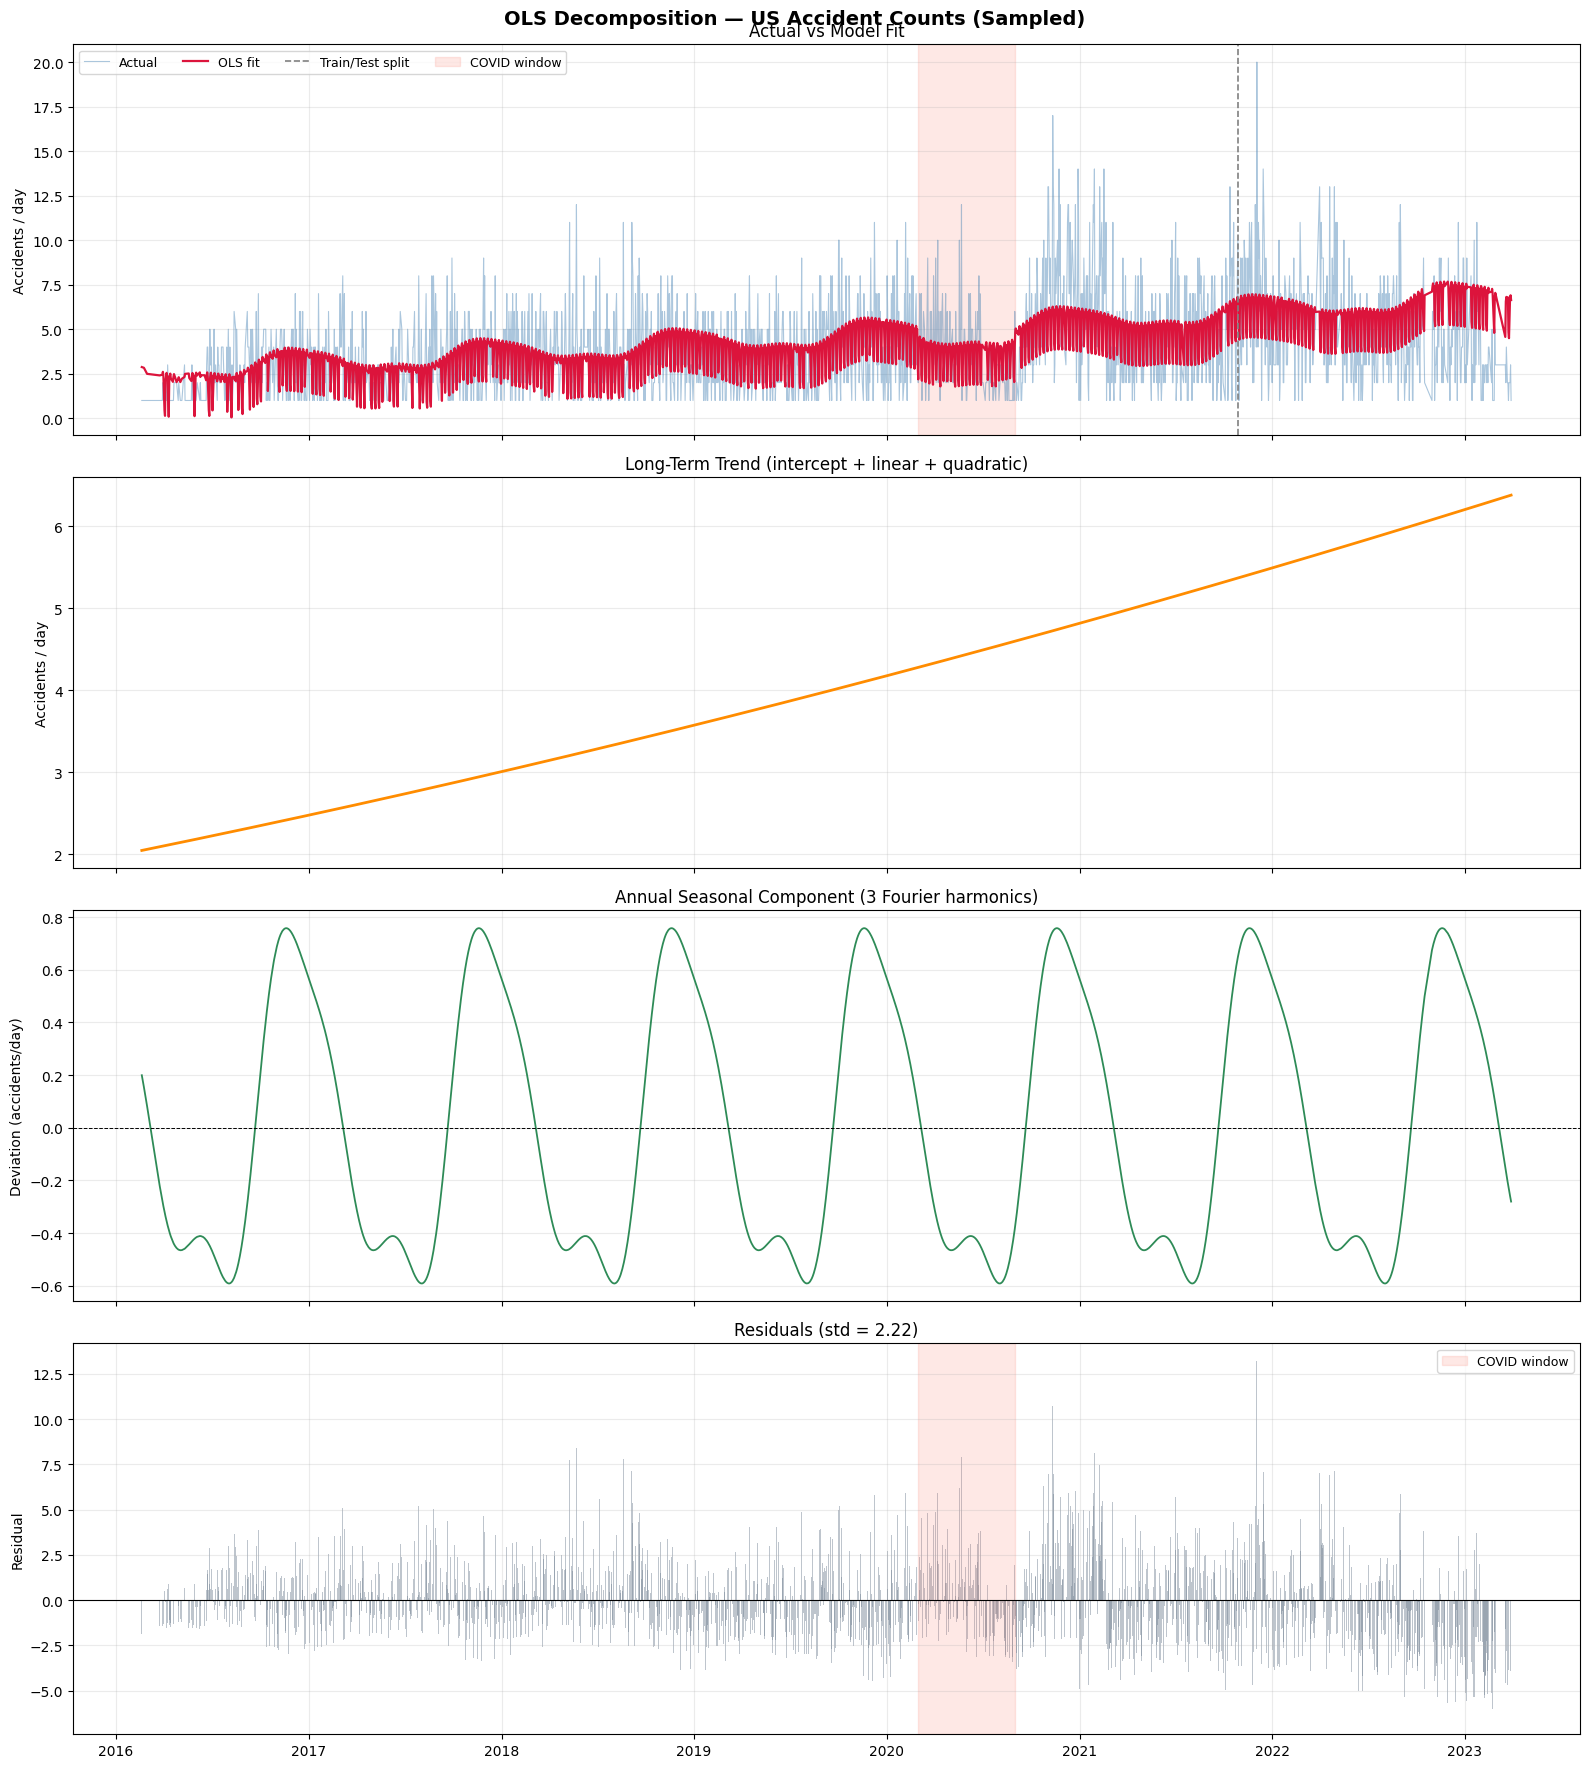

In [7]:
# four-panel decomposition plot
fig, axes = plt.subplots(4, 1, figsize=(16, 18), sharex=True)
fig.suptitle('OLS Decomposition — US Accident Counts (Sampled)', fontsize=14, fontweight='bold')

split_date = dates.iloc[split]

def shade_covid(ax):
    ax.axvspan(covid_start, covid_end, color='salmon', alpha=0.18, label='COVID window')

ax = axes[0]
ax.plot(dates, y,          color='steelblue', alpha=0.45, lw=0.8, label='Actual')
ax.plot(dates, y_pred_all, color='crimson',   lw=1.6,             label='OLS fit')
ax.axvline(split_date, color='gray', ls='--', lw=1.2, label='Train/Test split')
shade_covid(ax)
ax.set_title('Actual vs Model Fit')
ax.set_ylabel('Accidents / day')
ax.legend(ncol=4, fontsize=9)
ax.grid(alpha=0.25)

ax = axes[1]
ax.plot(dates, trend_comp, color='darkorange', lw=2)
ax.set_title('Long-Term Trend (intercept + linear + quadratic)')
ax.set_ylabel('Accidents / day')
ax.grid(alpha=0.25)

ax = axes[2]
ax.plot(dates, annual_comp, color='seagreen', lw=1.3)
ax.axhline(0, color='black', lw=0.7, ls='--')
ax.set_title('Annual Seasonal Component (3 Fourier harmonics)')
ax.set_ylabel('Deviation (accidents/day)')
ax.grid(alpha=0.25)

ax = axes[3]
ax.bar(dates, residuals, color='slategray', alpha=0.45, width=1.5)
ax.axhline(0, color='black', lw=0.8)
shade_covid(ax)
ax.set_title(f'Residuals (std = {residuals.std():.2f})')
ax.set_ylabel('Residual')
ax.legend(fontsize=9)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

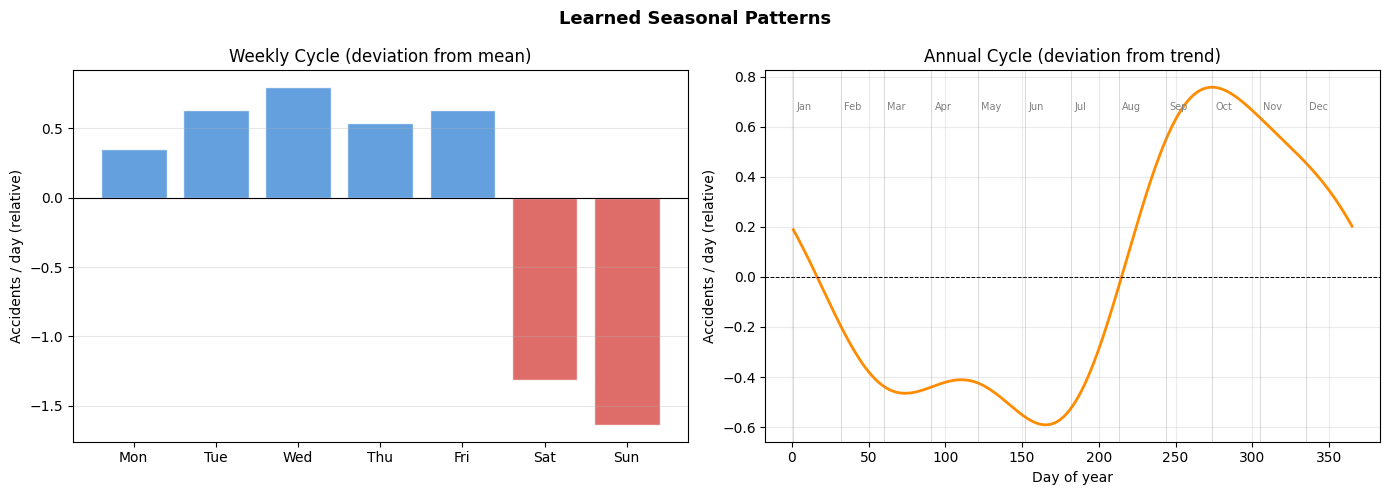

In [8]:
# evaluate the weekly and annual Fourier profiles across their full cycles
dow_range = np.arange(7)
W = np.column_stack([
    np.sin(2 * np.pi * k * dow_range / 7) if i % 2 == 0
    else np.cos(2 * np.pi * k * dow_range / 7)
    for k in range(1, 4) for i in range(2)
])
weekly_profile = W @ beta[IDX_WEEKLY]

doy = np.arange(1, 366)
A = np.column_stack([
    np.sin(2 * np.pi * k * doy / 365.25) if i % 2 == 0
    else np.cos(2 * np.pi * k * doy / 365.25)
    for k in range(1, 4) for i in range(2)
])
annual_profile = A @ beta[IDX_ANNUAL]

day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Learned Seasonal Patterns', fontsize=13, fontweight='bold')

ax = axes[0]
colours = ['#4a90d9' if v >= 0 else '#d9534f' for v in weekly_profile]
ax.bar(day_names, weekly_profile, color=colours, alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Weekly Cycle (deviation from mean)')
ax.set_ylabel('Accidents / day (relative)')
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
ax.plot(doy, annual_profile, color='darkorange', lw=2)
ax.axhline(0, color='black', lw=0.7, ls='--')
month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
for ms, ml in zip(month_starts, month_labels):
    ax.axvline(ms, color='gray', lw=0.4, alpha=0.5)
    ax.text(ms + 2, annual_profile.max() * 0.88, ml, fontsize=7, color='gray')
ax.set_title('Annual Cycle (deviation from trend)')
ax.set_xlabel('Day of year')
ax.set_ylabel('Accidents / day (relative)')
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [9]:
# print key takeaways from the OLS model
peak_doy   = int(doy[np.argmax(annual_profile)])
trough_doy = int(doy[np.argmin(annual_profile)])
swing      = annual_profile.max() - annual_profile.min()

print('Weekly pattern')
for d, v in zip(day_names, weekly_profile):
    print(f'  {d}: {v:+.2f}')

print(f'\nAnnual pattern')
print(f'  Peak day of year  : {peak_doy}')
print(f'  Trough day of year: {trough_doy}')
print(f'  Peak-to-trough    : {swing:.2f} accidents/day')

covid_mask      = covid_dummy.astype(bool)
avg_trend_covid = trend_comp[covid_mask].mean()
covid_pct       = abs(beta[IDX_COVID]) / avg_trend_covid * 100 if avg_trend_covid else 0
print(f'\nCOVID-19 effect')
print(f'  Coefficient       : {beta[IDX_COVID]:+.2f} accidents/day')
print(f'  Estimated reduction: {covid_pct:.1f}%')

t_start, t_end = trend_comp[0], trend_comp[-1]
pct_change = (t_end / t_start - 1) * 100 if t_start else 0
print(f'\nLong-term trend')
print(f'  Start : {t_start:.2f} accidents/day')
print(f'  End   : {t_end:.2f} accidents/day')
print(f'  Change: {t_end - t_start:+.2f} ({pct_change:+.1f}%)')

Weekly pattern
  Mon: +0.35
  Tue: +0.63
  Wed: +0.80
  Thu: +0.54
  Fri: +0.63
  Sat: -1.31
  Sun: -1.64

Annual pattern
  Peak day of year  : 274
  Trough day of year: 165
  Peak-to-trough    : 1.35 accidents/day

COVID-19 effect
  Coefficient       : -0.53 accidents/day
  Estimated reduction: 11.9%

Long-term trend
  Start : 2.05 accidents/day
  End   : 6.38 accidents/day
  Change: +4.33 (+211.9%)


## Model 2: AR(7)

  intercept    +1.0891
  lag_1        +0.1734
  lag_2        +0.0718
  lag_3        +0.0233
  lag_4        +0.0261
  lag_5        +0.0638
  lag_6        +0.1660
  lag_7        +0.1894
Train R² = 0.2035
Test  R² = 0.1036


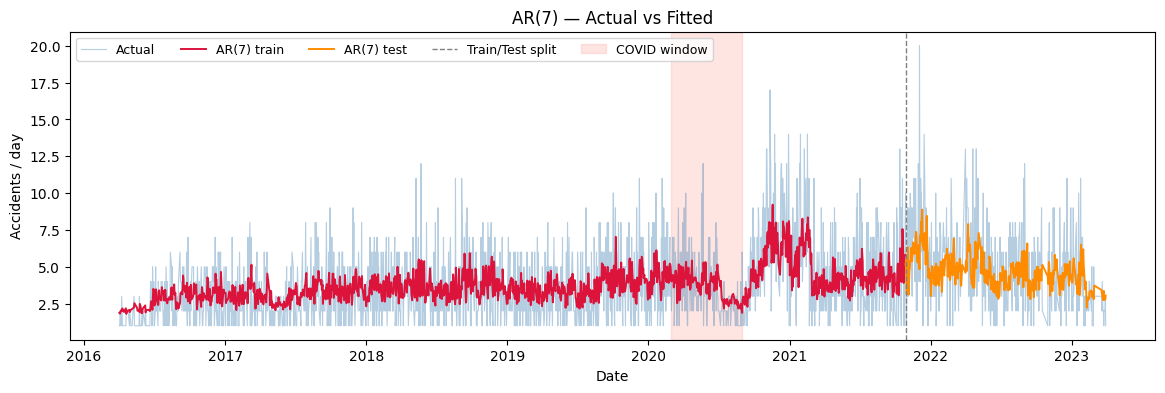

In [10]:
# use the past 7 days (one weekly cycle) as features to predict today
p    = 7
n_ar = len(y) - p

# each column is y shifted back by i+1 days
X_ar = np.column_stack([y[p - i - 1 : n_ar + p - i - 1] for i in range(p)])
X_ar = np.column_stack([np.ones(n_ar), X_ar])
y_ar = y[p:]

split_ar = split - p
X_ar_train, X_ar_test = X_ar[:split_ar], X_ar[split_ar:]
y_ar_train, y_ar_test = y_ar[:split_ar], y_ar[split_ar:]

# solve OLS normal equations
w_ar = np.dot(np.linalg.inv(np.dot(X_ar_train.T, X_ar_train)),
              np.dot(X_ar_train.T, y_ar_train))

# print lag weights
labels = ['intercept'] + [f'lag_{i+1}' for i in range(p)]
for name, b in zip(labels, w_ar):
    print(f'  {name:<12} {b:+.4f}')

y_ar_pred_train = X_ar_train @ w_ar
y_ar_pred_test  = X_ar_test  @ w_ar

print(f'Train R² = {r2(y_ar_train, y_ar_pred_train):.4f}')
print(f'Test  R² = {r2(y_ar_test,  y_ar_pred_test):.4f}')

dates_ar      = dates.iloc[p:].reset_index(drop=True)
split_date_ar = dates_ar.iloc[split_ar]

plt.figure(figsize=(14, 4))
plt.plot(dates_ar, y_ar, color='steelblue', alpha=0.4, lw=0.8, label='Actual')
plt.plot(dates_ar[:split_ar], y_ar_pred_train, color='crimson',    lw=1.4, label='AR(7) train')
plt.plot(dates_ar[split_ar:], y_ar_pred_test,  color='darkorange', lw=1.4, label='AR(7) test')
plt.axvline(split_date_ar, color='gray', ls='--', lw=1, label='Train/Test split')
plt.axvspan(covid_start, covid_end, color='salmon', alpha=0.2, label='COVID window')
plt.xlabel('Date')
plt.ylabel('Accidents / day')
plt.title('AR(7) — Actual vs Fitted')
plt.legend(ncol=5, fontsize=9)
plt.show();

## Model 3: SARMA(1,1)(1,1)₇ via Hannan-Rissanen

  intercept    +0.5249
  AR(1)        +0.2726
  MA(1)        -0.1370
  SAR(1)_7     +0.5882
  SMA(1)_7     -0.4420
Train R² = 0.1987
Test  R² = 0.1547


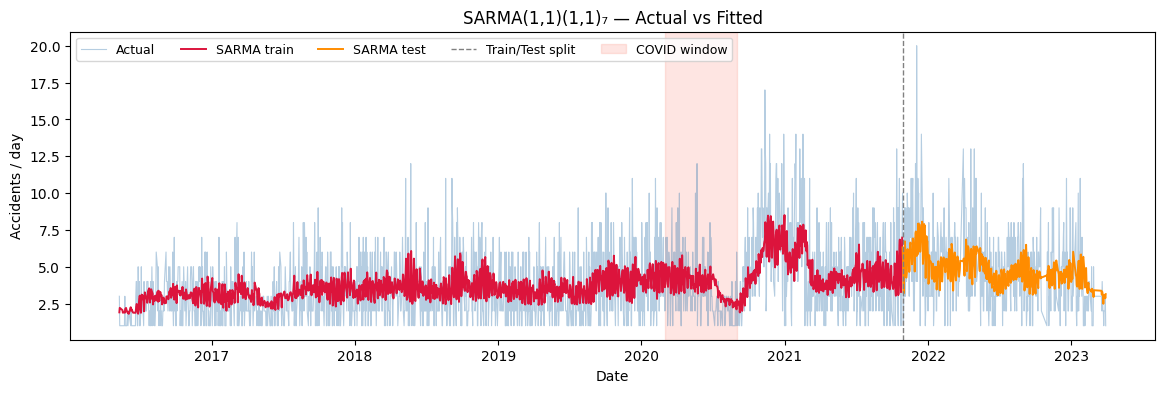

In [11]:
s = 7   # seasonal period (weekly)
m = 20  # long AR order used to approximate innovations

# step 1: fit a long AR(20) to get residual proxies for the MA terms
X_init = np.column_stack([np.ones(len(y) - m)] +
                          [y[m - i - 1 : len(y) - i - 1] for i in range(m)])
w_init      = np.dot(np.linalg.inv(np.dot(X_init.T, X_init)), np.dot(X_init.T, y[m:]))
eps_hat     = np.zeros(len(y))
eps_hat[m:] = y[m:] - X_init @ w_init

# step 2: build SARMA features using observed y values and residual proxies
# start at t0 = m+s so all lags are available
t0      = m + s
n_sarma = len(y) - t0

X_sarma = np.column_stack([
    np.ones(n_sarma),
    y[t0 - 1       : t0 - 1 + n_sarma],    # AR(1):    y_{t-1}
    eps_hat[t0 - 1 : t0 - 1 + n_sarma],    # MA(1):    eps_{t-1}
    y[t0 - s       : t0 - s + n_sarma],    # SAR(1)_7: y_{t-7}
    eps_hat[t0 - s : t0 - s + n_sarma],    # SMA(1)_7: eps_{t-7}
])
y_sarma = y[t0:]

split_sarma = split - t0
X_sarma_train, X_sarma_test = X_sarma[:split_sarma], X_sarma[split_sarma:]
y_sarma_train, y_sarma_test = y_sarma[:split_sarma], y_sarma[split_sarma:]

# solve OLS normal equations
w_sarma = np.dot(np.linalg.inv(np.dot(X_sarma_train.T, X_sarma_train)),
                 np.dot(X_sarma_train.T, y_sarma_train))

sarma_labels = ['intercept', 'AR(1)', 'MA(1)', 'SAR(1)_7', 'SMA(1)_7']
for name, b in zip(sarma_labels, w_sarma):
    print(f'  {name:<12} {b:+.4f}')

y_sarma_pred_train = X_sarma_train @ w_sarma
y_sarma_pred_test  = X_sarma_test  @ w_sarma

print(f'Train R² = {r2(y_sarma_train, y_sarma_pred_train):.4f}')
print(f'Test  R² = {r2(y_sarma_test,  y_sarma_pred_test):.4f}')

dates_sarma      = dates.iloc[t0:].reset_index(drop=True)
split_date_sarma = dates_sarma.iloc[split_sarma]

plt.figure(figsize=(14, 4))
plt.plot(dates_sarma, y_sarma, color='steelblue', alpha=0.4, lw=0.8, label='Actual')
plt.plot(dates_sarma[:split_sarma], y_sarma_pred_train, color='crimson',    lw=1.4, label='SARMA train')
plt.plot(dates_sarma[split_sarma:], y_sarma_pred_test,  color='darkorange', lw=1.4, label='SARMA test')
plt.axvline(split_date_sarma, color='gray', ls='--', lw=1, label='Train/Test split')
plt.axvspan(covid_start, covid_end, color='salmon', alpha=0.2, label='COVID window')
plt.xlabel('Date')
plt.ylabel('Accidents / day')
plt.title('SARMA(1,1)(1,1)₇ — Actual vs Fitted')
plt.legend(ncol=5, fontsize=9)
plt.show();

## Model Comparison

In [12]:
# compare all three models on the test set
print(f"{'Model':<25} {'R²':>8} {'MAE':>8} {'RMSE':>8}")
print('-' * 52)
print(f"{'OLS Decomposition':<25} {r2(y_test, y_pred_test):>8.4f} "
      f"{mae(y_test, y_pred_test):>8.3f} {rmse(y_test, y_pred_test):>8.3f}")
print(f"{'AR(7)':<25} {r2(y_ar_test, y_ar_pred_test):>8.4f} "
      f"{mae(y_ar_test, y_ar_pred_test):>8.3f} {rmse(y_ar_test, y_ar_pred_test):>8.3f}")
print(f"{'SARMA(1,1)(1,1)_7':<25} {r2(y_sarma_test, y_sarma_pred_test):>8.4f} "
      f"{mae(y_sarma_test, y_sarma_pred_test):>8.3f} {rmse(y_sarma_test, y_sarma_pred_test):>8.3f}")

Model                           R²      MAE     RMSE
----------------------------------------------------
OLS Decomposition          -0.0461    2.258    2.795
AR(7)                       0.1036    1.986    2.587
SARMA(1,1)(1,1)_7           0.1547    1.944    2.512


## Discussion

Across all three models, the test performance ended up being fairly modest, which isn’t too surprising. With only 10,000 rows, the daily counts average around four accidents per day, so there’s just a lot of noise compared to the actual signal. That makes it pretty difficult for any model to consistently pick up meaningful patterns over time.

The OLS decomposition struggled the most, with a negative test R², which basically means it did worse than just predicting the average. A big part of the issue is that the quadratic trend fits the training data but then overshoots when extended into the test period, where accident counts are both higher and more unpredictable. It still captures patterns that make intuitive sense, like the weekly cycle, seasonal trends, and the COVID dip, but those don’t translate into strong out-of-sample performance.

The AR(7) model does a bit better because it leans on recent data instead of trying to project a long-term trend. By using values from the previous week, it stays grounded in what’s actually happening in the series and adjusts more naturally as things change. The strongest signals come from the most recent day and the same day from the week before, which lines up with the idea that there’s both short-term momentum and a weekly rhythm.

The SARMA(1,1)(1,1)₇ model performs the best overall. It builds on the autoregressive approach by also accounting for past errors, which helps smooth things out. The biggest takeaway is that the same day from the previous week is still the most useful predictor, while the moving average part helps correct for unusually high or low values by pulling things back toward the mean. If this were applied to the full dataset with millions of records, where daily counts are much higher, all of the models would likely perform better since the signal would be a lot clearer relative to the noise.